# Phenotype Profile Matching: Classic Semantic Similarity vs LLM Embeddings

A core use of semantic similarity is matching a **patient's phenotype profile** to
**disease profiles**, as tools like Exomiser and Phenomizer do. This notebook compares
ontology-based methods with LLM-embedding methods on a small, controlled version of
that task. All methods run through the same OAK interfaces.

**Task.** We take a pool of 60 OMIM diseases annotated in HPO. For each disease we simulate
three noisy "patients":

- 3 of the disease's phenotypes are sampled;
- each is replaced, with probability 0.8, by an ancestor 1 or 2 levels up (imprecise
  annotation);
- 4 confounding phenotypes are added, drawn from the *other* diseases in the pool.

Every method then ranks all 60 diseases against each patient, and we record the rank of the
true disease. (The noise levels were chosen so the task is neither trivial nor hopeless;
with milder noise every method scores close to perfectly.)

**Methods**

| family | method | description |
|---|---|---|
| ontology | Jaccard BMA | best-match average of pairwise ancestor-set Jaccard |
| ontology | Resnik BMA | best-match average of the information content of the most informative common ancestor |
| ontology | flattened closure | Jaccard of the union of all ancestors of the two profiles (one vector per profile) |
| embedding | cosine BMA | best-match average of pairwise cosine, for each OLS model |
| embedding | mean vector | cosine of the averaged term vectors (one vector per profile), for each OLS model |

The "flattened" and "mean vector" methods merge each profile into a single vector. That
is what makes them easy to put in an off-the-shelf vector database, so it is worth
knowing how much accuracy that costs.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="eutils")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# reference palette (categorical slots in fixed order; sequential blue ramp)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})
SEQUENTIAL = sns.blend_palette(["#f0efec", "#86b6ef", "#2a78d6", "#0d366b"], as_cmap=True)

In [2]:
import random

import numpy as np
import pandas as pd

from oaklib import get_adapter
from oaklib.datamodels.vocabulary import IS_A
from oaklib.utilities.embeddings.closure_embeddings import closure_embeddings
from oaklib.utilities.embeddings.vector_utils import cosine_similarity_matrix, jaccard_similarity_matrix

hp = get_adapter("sqlite:obo:hp")
ols = get_adapter("ols:hp")
MODELS = ols.embedding_models()

## Disease profiles and simulated patients

Disease annotations come from the HPO `phenotype.hpoa` file. We keep OMIM diseases with
10 to 30 positive phenotype annotations and sample a pool of 60.

In [3]:
HPOA = "https://github.com/obophenotype/human-phenotype-ontology/releases/latest/download/phenotype.hpoa"
hpoa = pd.read_csv(HPOA, sep="\t", comment="#", dtype=str)
hpoa = hpoa[(hpoa.aspect == "P") & hpoa.qualifier.isna() & hpoa.database_id.str.startswith("OMIM:")]
profiles = hpoa.groupby("database_id").hpo_id.apply(lambda x: sorted(set(x)))
disease_names = hpoa.groupby("database_id").disease_name.first()
profiles = profiles[profiles.apply(len).between(10, 30)]

rng = random.Random(7)
pool = sorted(rng.sample(list(profiles.index), 60))
pool_terms = sorted({t for d in pool for t in profiles[d]})
parents = {}
for s, _, o in hp.relationships(predicates=[IS_A]):
    parents.setdefault(s, []).append(o)

def generalize(t, levels):
    for _ in range(levels):
        if not parents.get(t):
            break
        t = rng.choice(parents[t])
    return t

def noisy_patient(disease, n=3, p_imprecise=0.8, n_confounders=4):
    q = [generalize(t, rng.choice([1, 2])) if rng.random() < p_imprecise else t
         for t in rng.sample(profiles[disease], n)]
    others = [t for t in pool_terms if t not in profiles[disease]]
    return q + rng.sample(others, n_confounders)

patients = [(d, noisy_patient(d)) for d in pool for _ in range(3)]
all_terms = sorted(set(pool_terms) | {t for _, q in patients for t in q})
print(f"{len(pool)} diseases, {len(patients)} patients, {len(all_terms)} distinct phenotype terms")
example, example_patient = patients[0]
print(disease_names[example])
print("  patient:", [hp.label(t) for t in example_patient])

60 diseases, 180 patients, 930 distinct phenotype terms
Keratosis palmoplantaris striata I
  patient: ['Abnormal nail morphology', 'Abnormality of nail color', 'Hyperkeratosis', 'Severe global developmental delay', 'Bronchiectasis', 'Postnatal growth retardation', 'Abnormal pyramidal sign']


## The OAK API, for one patient and one disease

The interface returns a full best-match breakdown. Below we compute the same quantities
in bulk with numpy, so all methods can be scored quickly.

In [4]:
sim = ols.embedding_termset_similarity(
    example_patient, profiles[example], model="text-embedding-3-large_pca512", labels=True
)
print("best match average:", round(sim.average_score, 3))
for bm in sim.subject_best_matches.values():
    print(f"  {bm.match_source_label} -> {bm.match_target_label} ({bm.score:.2f})")

best match average: 0.652
  Abnormal nail morphology -> Nail dystrophy (0.86)
  Abnormality of nail color -> Yellow nails (0.79)
  Hyperkeratosis -> Orthokeratotic hyperkeratosis (0.84)
  Severe global developmental delay -> Nail dystrophy (0.30)
  Bronchiectasis -> Hyperhidrosis (0.35)
  Postnatal growth retardation -> Nail dystrophy (0.36)
  Abnormal pyramidal sign -> Streaks of hyperkeratosis along each finger onto the palm (0.47)


## Vectors and scores

Closure vectors for all terms are built in one call, so they share a vocabulary.
Information content (IC) for Resnik is computed from the ontology structure, so each
dimension of the closure vector can carry its ancestor's IC.

In [5]:
ids, vocab, C = closure_embeddings(hp, all_terms)
cix = {t: i for i, t in enumerate(ids)}
ic = dict(hp.information_content_scores(vocab, object_closure_predicates=[IS_A]))
IC = np.array([ic.get(v, 0.0) for v in vocab], dtype=np.float32)

vectors = {}
for model in MODELS:
    mids, M = ols.entity_embeddings(all_terms, model=model)
    vectors[model] = dict(zip(mids, M))
print({m: len(v) for m, v in vectors.items()})

{'harrier-oss-v1-27b_pca512': 930, 'llama-embed-nemotron-8b_pca512': 930, 'text-embedding-3-large_pca512': 930, 'text-embedding-3-small_pca512': 930}


In [6]:
def bma(S):
    # symmetric best-match average over a (patient x disease) similarity matrix
    return 0.5 * (S.max(axis=1).mean() + S.max(axis=0).mean())

def resnik_matrix(a, b):
    # IC of the most informative common ancestor, for every pair of terms
    A, B = C[[cix[t] for t in a]], C[[cix[t] for t in b]]
    return (A[:, None, :] * B[None, :, :] * IC).max(axis=2)

def score_all(patient, disease):
    p_rows, d_rows = C[[cix[t] for t in patient]], C[[cix[t] for t in disease]]
    scores = {
        ("ontology", "Jaccard BMA"): bma(jaccard_similarity_matrix(p_rows, d_rows)),
        ("ontology", "Resnik BMA"): bma(resnik_matrix(patient, disease)),
        ("ontology", "flattened closure"): jaccard_similarity_matrix(
            p_rows.max(axis=0, keepdims=True), d_rows.max(axis=0, keepdims=True))[0, 0],
    }
    for model in MODELS:
        v = vectors[model]
        P = np.array([v[t] for t in patient if t in v])
        D = np.array([v[t] for t in disease if t in v])
        name = model.replace("_pca512", "")
        scores[("embedding: cosine BMA", name)] = bma(cosine_similarity_matrix(P, D))
        scores[("embedding: mean vector", name)] = cosine_similarity_matrix(
            P.mean(axis=0, keepdims=True), D.mean(axis=0, keepdims=True))[0, 0]
    return scores

rows = []
for i, (true_disease, patient) in enumerate(patients):
    for candidate in pool:
        for (family, method), score in score_all(patient, profiles[candidate]).items():
            rows.append((i, true_disease, candidate, family, method, score))
scores = pd.DataFrame(rows, columns=["patient", "disease", "candidate", "family", "method", "score"])
len(scores)

118800

## Results

For each of the 180 patients and each method, we find the rank of the true disease among
the 60 candidates (1 is best; ties share the average rank).

In [7]:
scores["rank"] = scores.groupby(["patient", "family", "method"]).score.rank(ascending=False, method="average")
true_ranks = scores[scores.disease == scores.candidate]
summary = true_ranks.groupby(["family", "method"])["rank"].agg(
    MRR=lambda r: (1 / r).mean(),
    hits_at_1=lambda r: (r <= 1).mean(),
    hits_at_5=lambda r: (r <= 5).mean(),
    median_rank="median",
)

# 95% bootstrap interval for MRR, resampling patients
boot_rng = np.random.default_rng(0)
rr = 1 / true_ranks.pivot_table(index="patient", columns=["family", "method"], values="rank")
samples = np.array([rr.iloc[boot_rng.integers(0, len(rr), len(rr))].mean().values for _ in range(2000)])
summary["MRR 95% CI low"] = pd.Series(np.percentile(samples, 2.5, axis=0), index=rr.columns)
summary["MRR 95% CI high"] = pd.Series(np.percentile(samples, 97.5, axis=0), index=rr.columns)
summary = summary.sort_values("MRR", ascending=False)
summary.round(3)

MRR  hits_at_1  hits_at_5  \
family                 method                                                 
ontology               Jaccard BMA              0.673      0.500      0.900   
                       Resnik BMA               0.564      0.389      0.817   
embedding: cosine BMA  text-embedding-3-large   0.536      0.372      0.756   
                       harrier-oss-v1-27b       0.509      0.317      0.783   
                       text-embedding-3-small   0.473      0.294      0.711   
ontology               flattened closure        0.456      0.289      0.661   
embedding: mean vector text-embedding-3-large   0.399      0.228      0.611   
embedding: cosine BMA  llama-embed-nemotron-8b  0.380      0.222      0.556   
embedding: mean vector harrier-oss-v1-27b       0.367      0.183      0.606   
                       llama-embed-nemotron-8b  0.309      0.167      0.456   
                       text-embedding-3-small   0.301      0.117      0.528   

                                                median_rank  MRR 95% CI low  \
family                 method                                                 
ontology               Jaccard BMA                      1.5           0.623   
                       Resnik BMA                       2.0           0.510   
embedding: cosine BMA  text-embedding-3-large           2.0           0.480   
                       harrier-oss-v1-27b               2.0           0.453   
                       text-embedding-3-small           3.0           0.419   
ontology               flattened closure                3.0           0.403   
embedding: mean vector text-embedding-3-large           4.0           0.346   
embedding: cosine BMA  llama-embed-nemotron-8b          4.5           0.330   
embedding: mean vector harrier-oss-v1-27b               4.0           0.317   
                       llama-embed-nemotron-8b          7.0           0.260   
                       text-embedding-3-small           5.0           0.256   

                                                MRR 95% CI high  
family                 method                                    
ontology               Jaccard BMA                        0.719  
                       Resnik BMA                         0.615  
embedding: cosine BMA  text-embedding-3-large             0.589  
                       harrier-oss-v1-27b                 0.560  
                       text-embedding-3-small             0.526  
ontology               flattened closure                  0.512  
embedding: mean vector text-embedding-3-large             0.452  
embedding: cosine BMA  llama-embed-nemotron-8b            0.431  
embedding: mean vector harrier-oss-v1-27b                 0.417  
                       llama-embed-nemotron-8b            0.357  
                       text-embedding-3-small             0.346

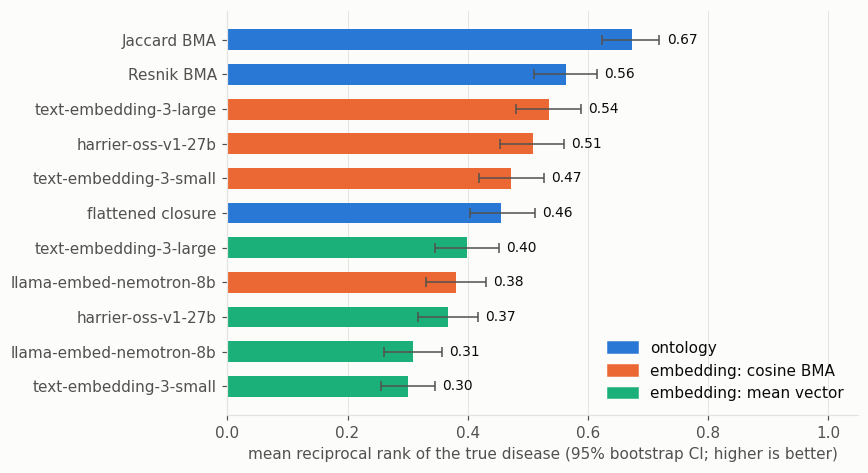

In [8]:
FAMILY_COLORS = {"ontology": BLUE, "embedding: cosine BMA": ORANGE, "embedding: mean vector": AQUA}
s = summary.reset_index()
fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(s))
ax.set_axisbelow(True)
err = [s.MRR - s["MRR 95% CI low"], s["MRR 95% CI high"] - s.MRR]
ax.barh(y, s.MRR, color=[FAMILY_COLORS[f] for f in s.family], height=0.6,
        xerr=err, error_kw={"ecolor": INK2, "elinewidth": 1, "capsize": 3})
ax.set_yticks(y, [f"{m}" for m in s.method])
for yi, v, hi in zip(y, s.MRR, s["MRR 95% CI high"]):
    ax.text(hi + 0.012, yi, f"{v:.2f}", va="center", fontsize=9, color=INK)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("mean reciprocal rank of the true disease (95% bootstrap CI; higher is better)")
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
ax.legend(handles, FAMILY_COLORS.keys(), frameon=False, loc="lower right")
fig.tight_layout()

## Discussion

- **The ontology wins, but not by a mile.** Best-match average over ancestor-set Jaccard
  is the strongest method here. The best text-embedding models (text-embedding-3-large,
  harrier) come next, close to Resnik, even though they never see the ontology graph. They
  do well because an imprecise annotation and its more specific counterpart usually share
  wording ("Abnormal nail morphology" vs "Nail dystrophy").
- **Resnik is below Jaccard** in this setup. One likely reason (not tested here): IC is
  computed from ontology structure rather than annotation frequencies, and Resnik rewards a
  single very specific shared ancestor. The confounders are real phenotypes of other
  diseases, so they can supply exactly such a match.
- **Merging a profile into one vector costs accuracy, for every kind of vector.** The
  flattened closure is 0.22 MRR below Jaccard BMA, and the mean vector is below cosine BMA
  for every model (by 0.07 for nemotron and 0.14 to 0.17 for the others). Single-vector profiles are what make an
  off-the-shelf vector database usable, so this gap is the price of that convenience. It
  is consistent with the "sets of vectors vs merged vectors" concern.
- **Model choice matters.** nemotron trails the other three models, consistent with its
  weaker results in the subsumption notebook.

**Caveats.** This is a small, synthetic benchmark: 60 diseases, 3 simulated patients per
disease, and a simple noise model whose settings strongly affect absolute scores (with
milder noise every method is near-perfect). Overlapping intervals in the chart mean those
methods are not distinguishable at this sample size. The benchmark is meant to show how to
run such comparisons with OAK, not to settle which method is best. To make it more
realistic, increase the pool size, use annotation-frequency IC, add label + definition
embeddings via the `llm:` adapter, or use real patient profiles. Vectors are cached
locally, so re-runs only fetch new terms from OLS.